In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Load the RFM Dataset

In [2]:
rfm = pd.read_csv("../data/processed/rfm_data.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


Check Dataset

In [3]:
rfm.info()
rfm.describe()
rfm.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   int64  
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.7 KB


(4338, 4)

Assign RFM Scores

Recency Score

Lower Recency = Better

In [4]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

Frequency Score

Higher Frequency = Better

In [5]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

Monetary Score

Higher Spending = Better

In [6]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

Create RFM Score

In [7]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


Customer Segmentation

In [8]:
def segment_customer(row):

    r = int(row["R_Score"])
    f = int(row["F_Score"])

    if r >= 4 and f >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "New Customers"

    elif r >= 3 and f >= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

In [9]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [10]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,5,115,Lost Customers
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,New Customers
4,12350,310,1,334.40,1,1,2,112,Lost Customers


Count Each Segment

In [11]:
rfm["Segment"].value_counts()

Segment
Lost Customers         1229
Champions              1139
Potential Loyalists     687
At Risk                 643
Loyal Customers         321
New Customers           319
Name: count, dtype: int64

Plot Customer Segments

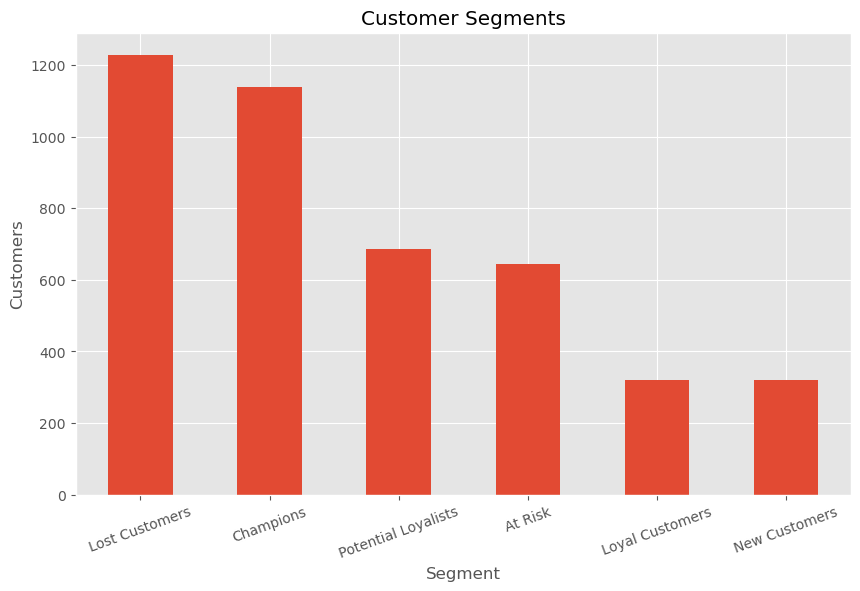

In [12]:
plt.figure(figsize=(10,6))

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Customers")

plt.xticks(rotation=20)

plt.show()

Pie Chart

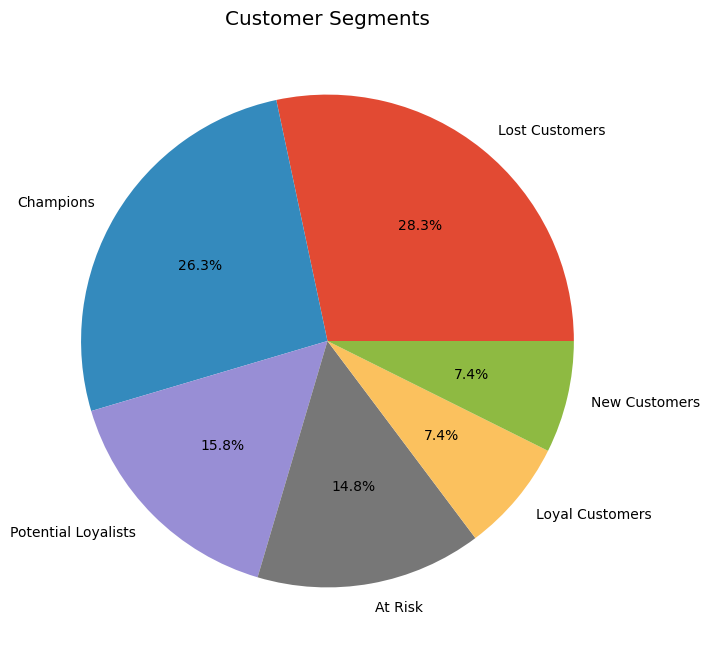

In [13]:
plt.figure(figsize=(8,8))

rfm["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Customer Segments")

plt.show()

Segment Summary

In [14]:
rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,152.844479,3.404355,1241.139208
Champions,13.311677,9.986831,5191.766533
Lost Customers,196.015460,1.087876,477.675225
Loyal Customers,50.582555,5.682243,2410.810654
New Customers,18.517241,1.241379,455.234295
Potential Loyalists,36.295488,2.053857,974.645546


Top Customers

In [15]:
rfm.sort_values(
    by="Monetary",
    ascending=False
).head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1689,14646,2,73,280206.02,5,5,5,555,Champions
4201,18102,1,60,259657.30,5,5,5,555,Champions
3728,17450,8,46,194390.79,5,5,5,555,Champions
3008,16446,1,2,168472.50,5,3,5,535,Potential Loyalists
1879,14911,1,201,143711.17,5,5,5,555,Champions
55,12415,24,21,124914.53,4,5,5,455,Champions
1333,14156,10,55,117210.08,5,5,5,555,Champions
3771,17511,3,31,91062.38,5,5,5,555,Champions
2702,16029,39,63,80850.84,3,5,5,355,Loyal Customers
0,12346,326,1,77183.60,1,1,5,115,Lost Customers


Save Dataset

In [16]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

# Customer Segmentation Insights

## Champions
- High spending
- Purchase frequently
- Purchased recently

## Loyal Customers
- Frequent buyers
- Strong customer relationship
- Good candidates for loyalty programs

## Potential Loyalists
- Active customers with growth potential
- Can be nurtured through personalized offers

## New Customers
- Recent purchasers
- Need onboarding and engagement

## At Risk
- Previously active customers who haven't purchased recently
- Re-engagement campaigns are recommended

## Lost Customers
- Inactive for a long time
- Low purchase frequency
- Win-back campaigns may be considered